In [38]:
# Import pandas for handling datasets and data manipulation
import pandas as pd

# Import matplotlib for creating visualizations and graphs
import matplotlib.pyplot as plt

# Import seaborn for better-looking statistical plots
import seaborn as sns

# Import time series forecasting models from statsmodels
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.api import ExponentialSmoothing

In [39]:
customers = pd.read_csv(r"C:\Users\0314b\Downloads\customers_cleaned.csv")
products = pd.read_csv(r"C:\Users\0314b\Downloads\products_cleaned.csv")
transactions = pd.read_csv(r"C:\Users\0314b\Downloads\transactions_cleaned.csv")


print("Datasets loaded successfully")

Datasets loaded successfully


In [41]:
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])

In [42]:
# Convert the Transaction_Date column into datetime format
# This allows pandas to perform time-based operations such as grouping by month

In [43]:
# Extract the month from the transaction date
# .dt.to_period('M') groups the dates into monthly periods
transactions['Month'] = transactions['Transaction_Date'].dt.to_period('M')

# Aggregate the dataset by month and sum the Total_Cost to calculate monthly sales
monthly_sales = transactions.groupby('Month')['Total_Cost'].sum().reset_index()

# Convert the month column back into a datetime format for plotting later
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Display the resulting time series dataset
monthly_sales.head()

,Month,Total_Cost
0,2020-10,4849600.0
1,2020-11,47773600.0
2,2020-12,28806400.0
3,2021-01,47096000.0
4,2021-02,36142400.0


In [44]:
# Calculate a 3-month moving average of sales
# This smooths short-term fluctuations and highlights the overall trend
monthly_sales['MA3'] = monthly_sales['Total_Cost'].rolling(window=3).mean()

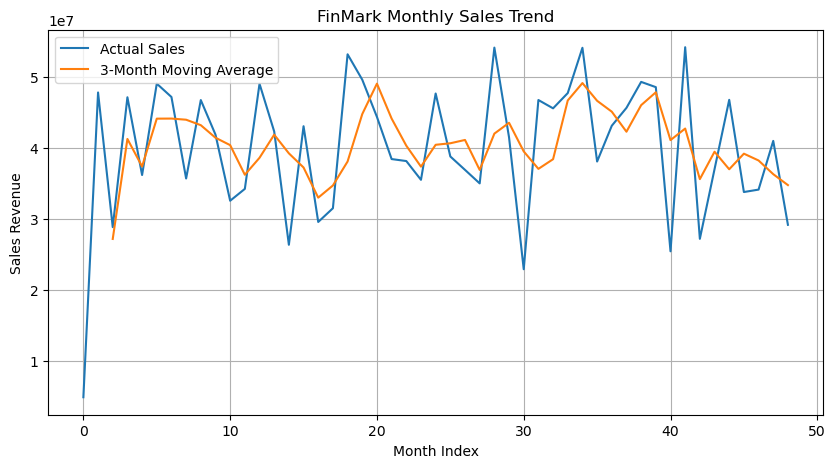

In [45]:
# Create a new figure for the graph
plt.figure(figsize=(10,5))

# Plot the actual monthly sales data
plt.plot(monthly_sales['Total_Cost'], label="Actual Sales")

# Plot the 3-month moving average to show the smoothed trend
plt.plot(monthly_sales['MA3'], label="3-Month Moving Average")

# Add a title to explain the visualization
plt.title("FinMark Monthly Sales Trend")

# Label the x-axis
plt.xlabel("Month Index")

# Label the y-axis
plt.ylabel("Sales Revenue")

# Display legend to identify each line
plt.legend()

# Add grid lines to make the graph easier to read
plt.grid()

# Show the plot
plt.show()

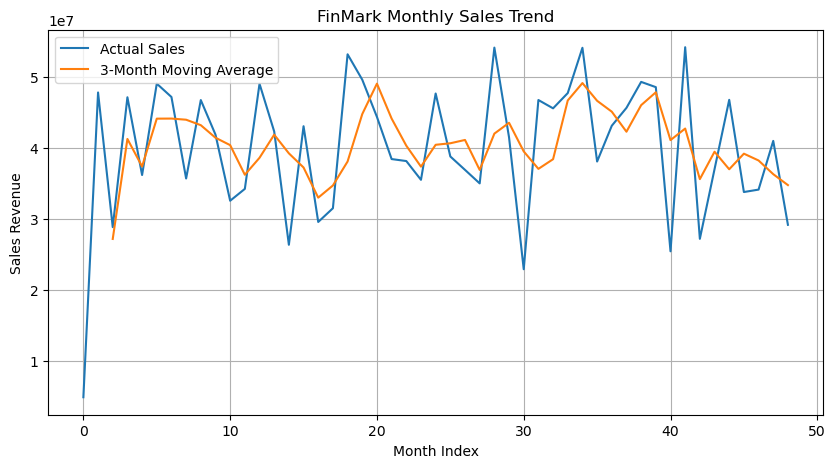

In [46]:
# Create a new figure for the graph
plt.figure(figsize=(10,5))

# Plot the actual monthly sales data
plt.plot(monthly_sales['Total_Cost'], label="Actual Sales")

# Plot the 3-month moving average to show the smoothed trend
plt.plot(monthly_sales['MA3'], label="3-Month Moving Average")

# Add a title to explain the visualization
plt.title("FinMark Monthly Sales Trend")

# Label the x-axis
plt.xlabel("Month Index")

# Label the y-axis
plt.ylabel("Sales Revenue")

# Display legend to identify each line
plt.legend()

# Add grid lines to make the graph easier to read
plt.grid()

# Show the plot
plt.show()

In [47]:
# Create the Simple Exponential Smoothing model
# This model gives more weight to recent observations in the dataset
ses_model = SimpleExpSmoothing(
    monthly_sales['Total_Cost']
).fit(
    smoothing_level=0.3,  # controls how strongly recent data affects the forecast
    optimized=False       # prevents the model from automatically adjusting parameters
)

# Store the smoothed values in a new column
monthly_sales['SES'] = ses_model.fittedvalues

In [48]:
# Create the Simple Exponential Smoothing model
# This model gives more weight to recent observations in the dataset
ses_model = SimpleExpSmoothing(
    monthly_sales['Total_Cost']
).fit(
    smoothing_level=0.3,  # controls how strongly recent data affects the forecast
    optimized=False       # prevents the model from automatically adjusting parameters
)

# Store the smoothed values in a new column
monthly_sales['SES'] = ses_model.fittedvalues

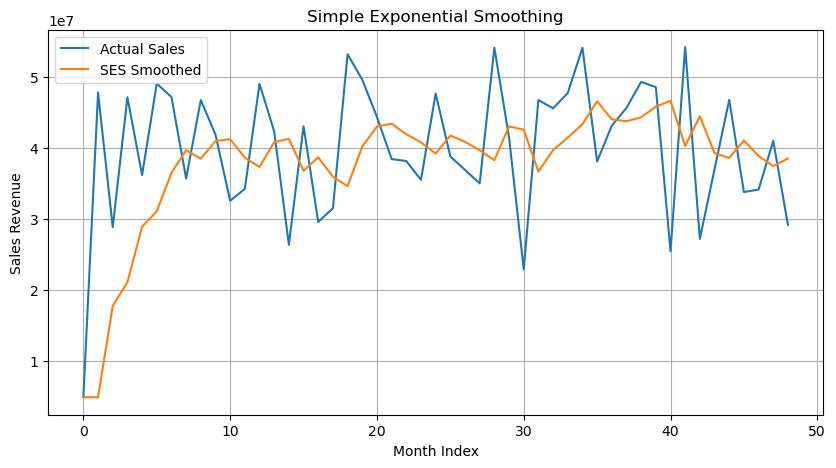

In [49]:
# Create a new figure for visualization
plt.figure(figsize=(10,5))

# Plot the original sales data
plt.plot(monthly_sales['Total_Cost'], label="Actual Sales")

# Plot the SES smoothed values
plt.plot(monthly_sales['SES'], label="SES Smoothed")

# Add chart title
plt.title("Simple Exponential Smoothing")

# Label the axes
plt.xlabel("Month Index")
plt.ylabel("Sales Revenue")

# Show legend
plt.legend()

# Add grid
plt.grid()

# Display the graph
plt.show()

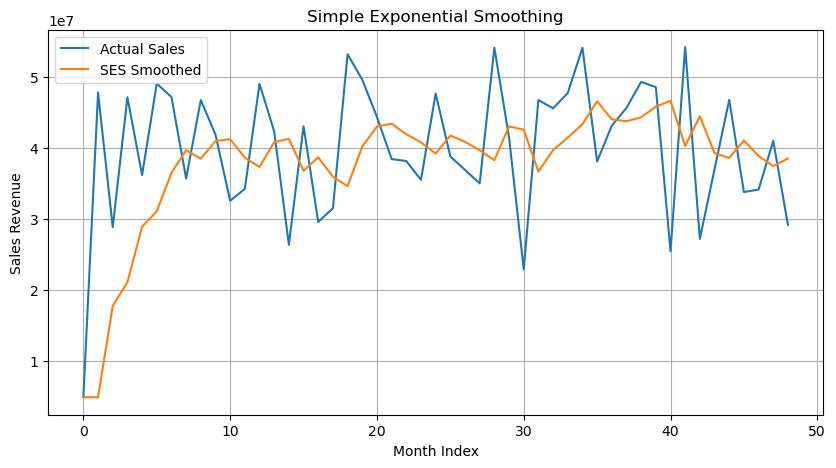

In [50]:
# Create a new figure for visualization
plt.figure(figsize=(10,5))

# Plot the original sales data
plt.plot(monthly_sales['Total_Cost'], label="Actual Sales")

# Plot the SES smoothed values
plt.plot(monthly_sales['SES'], label="SES Smoothed")

# Add chart title
plt.title("Simple Exponential Smoothing")

# Label the axes
plt.xlabel("Month Index")
plt.ylabel("Sales Revenue")

# Show legend
plt.legend()

# Add grid
plt.grid()

# Display the graph
plt.show()

In [51]:
# Normalize sales values to reduce convergence issues caused by large numbers
scaled_sales = monthly_sales['Total_Cost'] / 100000

# Create Holt's Exponential Smoothing model
# This model captures the trend in the time series
holt_model = ExponentialSmoothing(
    scaled_sales,
    trend='add',                     # additive trend assumption
    initialization_method='estimated'  # automatically estimate initial values
).fit()

# Store the fitted trend values and convert them back to original scale
monthly_sales['Holt_Trend'] = holt_model.fittedvalues * 100000

In [52]:
# Use the trained Holt model to forecast the next 6 months of sales
forecast = holt_model.forecast(6)

# Display the forecast values
forecast

49    357.627588
50    351.575850
51    345.524113
52    339.472375
53    333.420637
54    327.368900
dtype: float64

In [53]:
# Generate future monthly dates starting from the last month in the dataset
future_months = pd.date_range(
    start=monthly_sales['Month'].iloc[-1],  # last available month
    periods=7,                              # generate 7 months including the starting point
    freq='ME'                               # ME = month end frequency
)[1:]                                        # remove the first value since it is the current month

In [54]:
# Combine the forecasted sales values with the generated future months
forecast_df = pd.DataFrame({
    "Month": future_months,
    "Forecasted_Sales": forecast.values
})

# Display the forecast table
forecast_df

,Month,Forecasted_Sales
0,2024-11-30,357.627588
1,2024-12-31,351.575850
2,2025-01-31,345.524113
3,2025-02-28,339.472375
4,2025-03-31,333.420637
5,2025-04-30,327.368900


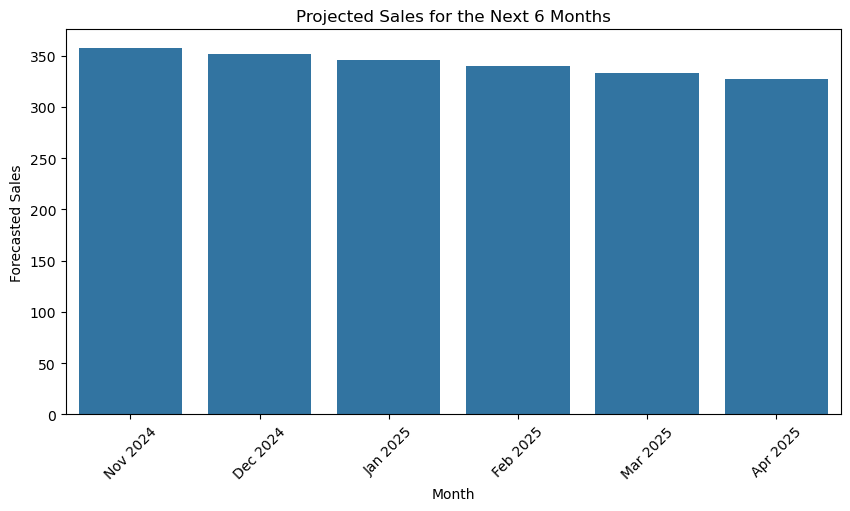

In [55]:
# Create a new figure for the forecast visualization
plt.figure(figsize=(10,5))

# Create a bar chart showing projected sales for the next 6 months
sns.barplot(
    x=forecast_df['Month'].dt.strftime('%b %Y'),  # display months as readable labels
    y=forecast_df['Forecasted_Sales']
)

# Add chart title
plt.title("Projected Sales for the Next 6 Months")

# Label axes
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

# Rotate month labels for better readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [56]:
# Print a confirmation message indicating that the forecasting pipeline finished successfully
print("Milestone 2 forecasting model completed successfully.")
print("Six-month sales forecast generated and visualized.")

Milestone 2 forecasting model completed successfully.
Six-month sales forecast generated and visualized.
